# Lab 1 - MNIST CNN: Gradient vs Cập nhật Parabol

Notebook này minh họa 2 cách cập nhật tham số cho mạng CNN trên MNIST:
1. **Gradient Descent thủ công** (backpropagation + SGD tự cài đặt) — theo dõi train/val/test.
2. **Phương pháp Parabol** (không dùng backward/gradient) — nội suy bậc 2 trên hướng ngẫu nhiên, theo dõi train/val/test.

**Tập dữ liệu:**
- Train: 54,000 mẫu (90% của 60,000)
- Validation: 6,000 mẫu (10% của 60,000) — dùng để theo dõi quá trình học, phát hiện overfitting
- Test: 10,000 mẫu — đánh giá cuối cùng, **không** dùng trong huấn luyện


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiet bi dang dung:", device)


Thiet bi dang dung: cpu


## Tải dữ liệu MNIST và tạo DataLoader

Chia tập train gốc (60,000 mẫu) thành:
- **train_dataset** (54,000): dùng để cập nhật tham số mạng
- **val_dataset** (6,000): dùng để theo dõi hiệu quả học mà **không** tác động vào tham số

> Validation giúp phát hiện **overfitting**: nếu train_loss giảm nhưng val_loss tăng → mạng đang học thuộc lòng dữ liệu.


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Tải toàn bộ tập train gốc (60,000 mẫu) và tập test (10,000 mẫu)
full_train_dataset = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
test_dataset       = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# --- Chia train/validation ---
# 90% dùng để train, 10% dùng làm validation
# random_split dùng seed cố định để kết quả tái hiện được
val_size   = int(0.1 * len(full_train_dataset))   # 6,000 mẫu
train_size = len(full_train_dataset) - val_size    # 54,000 mẫu
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)  # seed đã khai báo ở cell trên
)

common_batch_size = 256


train_loader = DataLoader(train_dataset, batch_size=common_batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=common_batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=common_batch_size, shuffle=False, num_workers=0)

print(f"Số mẫu train   : {len(train_dataset):,}")
print(f"Số mẫu val     : {len(val_dataset):,}")
print(f"Số mẫu test    : {len(test_dataset):,}")
print(f"Batch size     : {common_batch_size}")
print(f"Số batch/epoch : {len(train_loader)} (train), {len(val_loader)} (val)")


Số mẫu train   : 54,000
Số mẫu val     : 6,000
Số mẫu test    : 10,000
Batch size     : 256
Số batch/epoch : 211 (train), 24 (val)


## Xem nhanh một vài mẫu MNIST
Hiển thị 8 ảnh đầu tiên của một mini-batch để kiểm tra dữ liệu đã được đọc đúng.


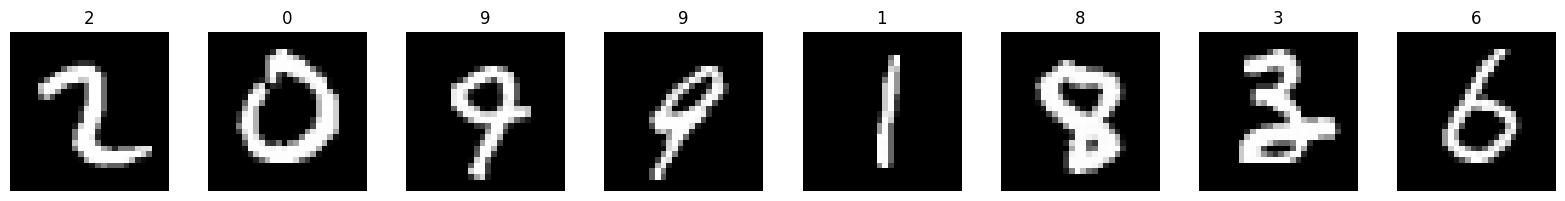

In [3]:
images, labels = next(iter(train_loader))
images = images[:8]
labels = labels[:8]

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze().numpy(), cmap="gray")
    ax.set_title(int(labels[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


## Định nghĩa mô hình CNN

Kiến trúc `SimpleCNN` xử lý ảnh đầu vào kích thước $1 \times 28 \times 28$ qua các bước sau:

**Khối `self.features` — trích xuất đặc trưng:**

| Layer | Công thức kích thước output | Code tương ứng |
|-------|-----------------------------|----------------|
| Conv2d(1→16, k=3, p=1) | $16 \times 28 \times 28$ | `nn.Conv2d(1, 16, kernel_size=3, padding=1)` |
| ReLU | $16 \times 28 \times 28$ (giữ nguyên, âm→0) | `nn.ReLU()` |
| MaxPool2d(2) | $16 \times 14 \times 14$ | `nn.MaxPool2d(2)` |
| Conv2d(16→32, k=3, p=1) | $32 \times 14 \times 14$ | `nn.Conv2d(16, 32, kernel_size=3, padding=1)` |
| ReLU | $32 \times 14 \times 14$ | `nn.ReLU()` |
| MaxPool2d(2) | $32 \times 7 \times 7$ | `nn.MaxPool2d(2)` |

**Khối `self.classifier` — phân loại:**

| Layer | Công thức | Code tương ứng |
|-------|-----------|----------------|
| Flatten | $32 \times 7 \times 7 = 1568$ chiều | `nn.Flatten()` |
| Linear(1568→64) + ReLU | $h = \text{ReLU}(W_1 x + b_1)$, $W_1 \in \mathbb{R}^{64 \times 1568}$ | `nn.Linear(32*7*7, 64)` |
| Linear(64→10) | $z = W_2 h + b_2$, $z \in \mathbb{R}^{10}$ (logits) | `nn.Linear(64, 10)` |

Output cuối là **logits** $z \in \mathbb{R}^{10}$ — chưa qua softmax, mỗi giá trị tương ứng một chữ số 0–9.

Tổng tham số cần học: $\theta = \{W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}, W_1, b_1, W_2, b_2, \ldots\}$


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## Hàm huấn luyện và đánh giá — Phương pháp Gradient Descent

Tính hàm lỗi từ logits (chưa qua softmax):

$$
E_B = \frac{1}{|B|} \sum_{i \in B} \left[ \underbrace{\log \sum_{k=0}^{9} e^{z_k^{(i)}}}_{\texttt{logsumexp}} - \underbrace{z_{y_i}^{(i)}}_{\texttt{logit của nhãn đúng}} \right]
$$

Trong code: `logits.gather(1, targets.unsqueeze(1)).squeeze(1)` lấy đúng $z_{y_i}$ cho mỗi mẫu $i$.


In [5]:
def cross_entropy_from_logits(logits, targets):
    logsumexp = torch.logsumexp(logits, dim=1)                             # (batch,)
    true_class_logits = logits.gather(1, targets.unsqueeze(1)).squeeze(1)  # lấy logit của nhãn đúng
    return (logsumexp - true_class_logits).mean()                          # trung bình trên batch


Tính loss và accuracy trên toàn bộ loader mà **không cập nhật tham số**:

$$
\bar{E} = \frac{\sum_{i} E_i \cdot |B_i|}{\sum_{i} |B_i|}, \qquad \text{accuracy} = \frac{\text{số mẫu dự đoán đúng}}{\text{tổng số mẫu}}
$$

Dự đoán đúng khi: $\hat{y} = \arg\max_k z_k = y$ (nhãn thật).


In [6]:
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)                                # forward, không tính gradient
            loss = loss_fn(logits, y)

            total_loss    += loss.item() * x.size(0)        # nhân với batch size để tính trung bình đúng
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


Cập nhật **thủ công** theo SGD cơ bản:

$$
w \leftarrow w - \varepsilon \cdot \underbrace{\frac{\partial E_B}{\partial w}}_{\texttt{p.grad}}
$$

Tương đương code: `p -= lr * p.grad` với `lr` = $\varepsilon = 0.01$.


In [7]:
@torch.no_grad()
def manual_gradient_descent_step(model, lr):
    for p in model.parameters():
        if p.grad is not None:
            p -= lr * p.grad   # w ← w − lr * ∂L/∂w


Luồng xử lý mỗi mini-batch (kích thước 256):

$$
\underbrace{z = f(x;w)}_{\text{(1) forward}} \;\longrightarrow\; \underbrace{E_B = \frac{1}{256}\sum \ell(z_i, y_i)}_{\text{(2) hàm lỗi}} \;\longrightarrow\; \underbrace{\frac{\partial E_B}{\partial w}}_{\text{(3) backward (chain rule)}}\;\longrightarrow\; \underbrace{w \leftarrow w - \varepsilon \cdot \nabla_w E_B}_{\text{(4) cập nhật}}
$$

> **Tại sao `zero_grad()` trước backward?**  
> PyTorch mặc định **cộng dồn** gradient: `p.grad += ∂E/∂p`.  
> Nếu không gọi `zero_grad()`, gradient của batch này sẽ cộng thêm vào gradient batch trước → sai công thức.


In [8]:
def train_one_epoch_gradient(model, loader, loss_fn, lr):
    model.train()   # bật chế độ training (Dropout, BN hoạt động bình thường)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Bước 1: Xóa gradient cũ — nếu không xóa, gradient sẽ cộng dồn (PyTorch mặc định +=)
        model.zero_grad(set_to_none=True)

        # Bước 2 & 3: Forward + tính loss
        logits = model(x)
        loss = loss_fn(logits, y)

        # Bước 4: Backward — lan truyền ngược, tính ∂L/∂w bằng chain rule
        loss.backward()

        # Bước 5: Cập nhật tham số theo hướng ngược gradient
        manual_gradient_descent_step(model, lr)

        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


## Huấn luyện CNN — Phương pháp Gradient Descent

**Công thức cập nhật mỗi mini-batch** (`lr_grad = 0.01`, batch size = 256):

$$
w_{t+1} = w_t - \varepsilon \cdot \nabla_{w} E_B(w_t)
$$

Viết tường minh cho từng lớp:

$$
W^{(l)}_{t+1} = W^{(l)}_t - \varepsilon \cdot \frac{\partial E_B}{\partial W^{(l)}}, \qquad b^{(l)}_{t+1} = b^{(l)}_t - \varepsilon \cdot \frac{\partial E_B}{\partial b^{(l)}}
$$

**Cấu hình training:**
- `epochs_grad = 20` → lặp qua 54,000 mẫu train × 20 lần
- Mỗi epoch có $\lceil 54000/256 \rceil = 211$ bước cập nhật
- Tổng số lần cập nhật: $211 \times 20 = 4220$ bước


In [9]:
model_grad = SimpleCNN().to(device)
loss_fn    = cross_entropy_from_logits
lr_grad    = 0.01   # learning rate: kiểm soát độ lớn của mỗi bước cập nhật

history_grad = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "test_loss":  [], "test_acc":  [],
}

epochs_grad = 20
for epoch in range(1, epochs_grad + 1):

    train_loss, train_acc = train_one_epoch_gradient(model_grad, train_loader, loss_fn, lr_grad)
    val_loss, val_acc     = evaluate(model_grad, val_loader, loss_fn)
    test_loss, test_acc   = evaluate(model_grad, test_loader, loss_fn)

    history_grad["train_loss"].append(train_loss)
    history_grad["train_acc"].append(train_acc)
    history_grad["val_loss"].append(val_loss)
    history_grad["val_acc"].append(val_acc)
    history_grad["test_loss"].append(test_loss)
    history_grad["test_acc"].append(test_acc)

    print(
        f"[Gradient] Epoch {epoch:2d}/{epochs_grad} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


[Gradient] Epoch  1/20 | train_loss=1.5381, train_acc=0.6304 | val_loss=0.6106, val_acc=0.8222 | test_loss=0.5792, test_acc=0.8361
[Gradient] Epoch  2/20 | train_loss=0.4395, train_acc=0.8720 | val_loss=0.3615, val_acc=0.8910 | test_loss=0.3346, test_acc=0.9026
[Gradient] Epoch  3/20 | train_loss=0.3296, train_acc=0.9013 | val_loss=0.3210, val_acc=0.8990 | test_loss=0.2982, test_acc=0.9081
[Gradient] Epoch  4/20 | train_loss=0.2762, train_acc=0.9174 | val_loss=0.2628, val_acc=0.9238 | test_loss=0.2409, test_acc=0.9291
[Gradient] Epoch  5/20 | train_loss=0.2363, train_acc=0.9288 | val_loss=0.2313, val_acc=0.9315 | test_loss=0.2095, test_acc=0.9388
[Gradient] Epoch  6/20 | train_loss=0.2060, train_acc=0.9383 | val_loss=0.1985, val_acc=0.9438 | test_loss=0.1765, test_acc=0.9501
[Gradient] Epoch  7/20 | train_loss=0.1803, train_acc=0.9465 | val_loss=0.1737, val_acc=0.9480 | test_loss=0.1572, test_acc=0.9523
[Gradient] Epoch  8/20 | train_loss=0.1594, train_acc=0.9532 | val_loss=0.1611, val

## Trực quan hóa kết quả — Gradient Descent

Vẽ 3 đường trên cùng trục để so sánh tốc độ hội tụ và dấu hiệu overfitting:

**Biểu đồ Loss** (trái): kỳ vọng cả 3 đường giảm dần và **hội tụ gần nhau**:
$$
E_{\text{train}}(t) \approx E_{\text{val}}(t) \approx E_{\text{test}}(t) \;\longrightarrow\; \text{mô hình tổng quát hóa tốt}
$$

**Biểu đồ Accuracy** (phải): kỳ vọng cả 3 đường tăng dần và xấp xỉ nhau:
$$
\text{acc} = \frac{1}{N}\sum_{i=1}^N \mathbf{1}[\arg\max_k z_k^{(i)} = y_i]
$$


[Gradient] Accuracy cuối cùng — val: 97.45%  |  test: 97.93%


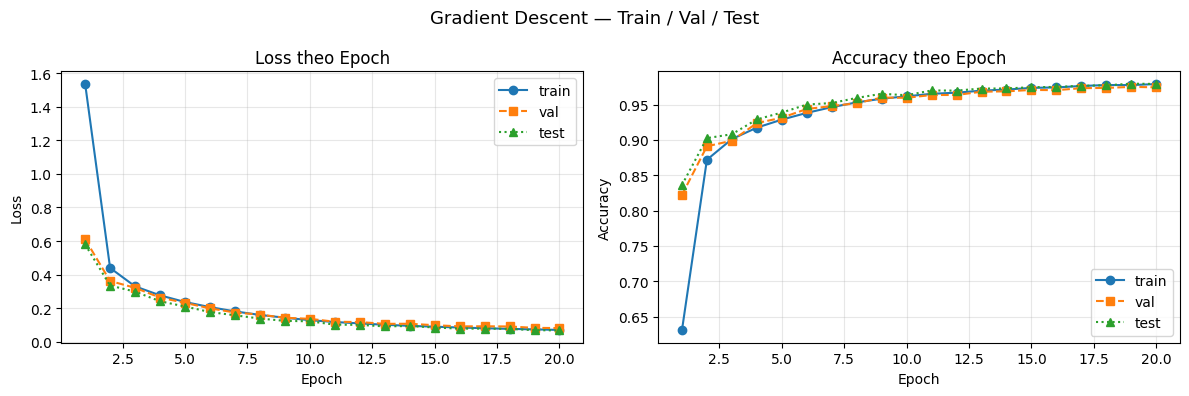

In [10]:
print(f"[Gradient] Accuracy cuối cùng — val: {history_grad['val_acc'][-1]*100:.2f}%  |  test: {history_grad['test_acc'][-1]*100:.2f}%")

epoch_axis = range(1, epochs_grad + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Gradient Descent — Train / Val / Test", fontsize=13)

# --- Biểu đồ Loss ---
axes[0].plot(epoch_axis, history_grad["train_loss"], marker="o", label="train")
axes[0].plot(epoch_axis, history_grad["val_loss"],   marker="s", label="val",  linestyle="--")
axes[0].plot(epoch_axis, history_grad["test_loss"],  marker="^", label="test", linestyle=":")
axes[0].set_title("Loss theo Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Biểu đồ Accuracy ---
axes[1].plot(epoch_axis, history_grad["train_acc"], marker="o", label="train")
axes[1].plot(epoch_axis, history_grad["val_acc"],   marker="s", label="val",  linestyle="--")
axes[1].plot(epoch_axis, history_grad["test_acc"],  marker="^", label="test", linestyle=":")
axes[1].set_title("Accuracy theo Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Cập nhật tham số bằng Phương pháp Parabol (không dùng backward)

Thay vì tính $\nabla_w E$ (cần backward), ta cố định một **hướng ngẫu nhiên** $d_t$ và tìm bước nhảy tối ưu $\alpha^*$ trên đường thẳng:

$$
\phi(\alpha) = E(w_t + \alpha \, d_t), \quad \alpha \in \mathbb{R}
$$


Lấy danh sách tham số cần học

Lọc ra các tensor có `requires_grad=True` — tức là những tham số $w$ sẽ được cập nhật:

$$
w = \{p \in \text{model.parameters()} \mid p.\text{requires\_grad} = \text{True}\}
$$

Hàm này dùng để snapshot và thao tác $w$ trực tiếp trong phương pháp Parabol (thay vì qua `optimizer`).


In [11]:
def trainable_params(model):
    return [p for p in model.parameters() if p.requires_grad]


Chuẩn hóa hướng

Sinh hướng ngẫu nhiên rồi chia cho norm để có **unit vector**:

$$
d_t \sim \mathcal{N}(0, I), \qquad d_t \leftarrow \frac{d_t}{\|d_t\|_2}
$$

Sau chuẩn hóa: $\|d_t\|_2 = 1$ → `delta` có đơn vị nhất quán ở mọi layer.


In [12]:
def normalize_direction(direction):
    sq_norm = torch.tensor(0.0, device=direction[0].device)
    for d in direction:
        sq_norm += (d * d).sum()    # tính bình phương norm
    norm = torch.sqrt(sq_norm).item()
    norm = max(norm, 1e-12)         # tránh chia cho 0
    return [d / norm for d in direction]


Cập nhật tham số

$$
w = w_{\text{base}} + \alpha \cdot d_t
$$

Trong code: `p.copy_(b + alpha * d)` với $\alpha \in \{-\delta, 0, +\delta\}$.


In [ ]:
@torch . no_grad ()
def update_params(params, base_params, direction, alpha):
    for p, b, d in zip(params, base_params, direction):
        p.copy_(b + alpha * d)


Tìm $\alpha^*$

Lấy 3 điểm lỗi tại $\alpha = -\delta, 0, +\delta$:

$$
E_- = \phi(-\delta), \quad E_0 = \phi(0), \quad E_+ = \phi(+\delta)
$$

Nội suy parabol $q(\alpha) = a\alpha^2 + b\alpha + c$ qua 3 điểm:

$$
c = E_0, \qquad a = \frac{E_- + E_+ - 2E_0}{2\delta^2} \;\text{(độ cong)}, \qquad b = \frac{E_+ - E_-}{2\delta} \;\text{(độ dốc tại } \alpha=0\text{)}
$$

Cực tiểu parabol (điều kiện $a > 0$):

$$
\alpha^* = -\frac{b}{2a} = \frac{\delta \,(E_- - E_+)}{2\,(E_- - 2E_0 + E_+)}
$$

Giới hạn: $\alpha^* \leftarrow \text{clip}(\alpha^*, -\alpha_{\max}, +\alpha_{\max})$ với `alpha_max = 0.05`.

**Trường hợp đặc biệt** (`|denom| ≤ 1e-12`): fallback chọn $\alpha \in \{-\delta, 0, +\delta\}$ có $E$ nhỏ nhất.


In [ ]:
def compute_alpha(E_minus, E_zero, E_plus, delta, alpha_max):

    denom = E_minus - 2 * E_zero + E_plus

    if abs(denom) > 1e-12:
        alpha = delta * (E_minus - E_plus) / (2 * denom)
    else:
        candidates = [(-delta, E_minus),
                      (0.0,   E_zero),
                      (delta,  E_plus)]
        alpha = min(candidates, key=lambda x: x[1])[0]

    alpha = max(-alpha_max, min(alpha_max, alpha))

    return alpha


Luồng xử lý mỗi mini-batch (không có `loss.backward()`):

$$
\underbrace{w_{\text{base}} = w_t}_{\text{(1) snapshot}} \;\to\; \underbrace{d_t \sim \mathcal{N}(0,I),\; \|d_t\|=1}_{\text{(2) hướng ngẫu nhiên}} \;\to\; \underbrace{E_-,\, E_0,\, E_+}_{\text{(3–5) 3 lần forward}} \;\to\; \underbrace{\alpha^*}_{\text{(6) nội suy parabol}} \;\to\; \underbrace{w_t + \alpha^* d_t}_{\text{(7) cập nhật}}
$$

$$
w_{t+1} = w_t + \alpha^* \cdot d_t
$$

**Chi phí tính toán:** 3 lần `model(x)` để lấy $E_-, E_0, E_+$ + 1 lần để tính metric sau cập nhật = **4 forward/batch** (so với 1 forward + 1 backward của Gradient Descent).


In [ ]:
def train_one_epoch_parabola(model, loader, loss_fn, delta=0.02, alpha_max=0.05, max_batches=None):
    model.train()
    params = trainable_params(model)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            # Bước 1: Chụp snapshot tham số gốc
            base_params = [p.detach().clone() for p in params]

            # Bước 2: Tạo hướng ngẫu nhiên và chuẩn hóa về unit vector
            direction = [torch.randn_like(p) for p in params]
            direction = normalize_direction(direction)

            # Bước 3: Tính E tại w − δd
            update_params(params, base_params, direction, -delta)
            E_minus = loss_fn(model(x), y).item()

            # Bước 4: Tính E tại w (vị trí gốc)
            update_params(params, base_params, direction, 0.0)
            E_zero = loss_fn(model(x), y).item()

            # Bước 5: Tính E tại w + δd
            update_params(params, base_params, direction, +delta)
            E_plus = loss_fn(model(x), y).item()

            # Bước 6: Tìm α* tối ưu bằng nội suy parabol
            alpha = compute_alpha(E_minus, E_zero, E_plus, delta, alpha_max)

            # Bước 7: Cập nhật tham số về vị trí tối ưu w_base + α* × d
            update_params(params, base_params, direction, alpha)

            # Đo lỗi sau khi cập nhật để ghi log
            logits = model(x)
            loss_after = loss_fn(logits, y)

        total_loss    += loss_after.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


## Huấn luyện CNN — Phương pháp Parabol

**Quy trình 1 mini-batch** (không có `loss.backward()`):

$$
\underbrace{w_{\text{base}} = w_t}_{\text{snapshot}} \;\to\; \underbrace{d_t \sim \mathcal{N}(0,I),\; \|d_t\|=1}_{\text{hướng ngẫu nhiên}} \;\to\; \underbrace{E_-,\, E_0,\, E_+}_{\text{3 lần forward}} \;\to\; \underbrace{\alpha^* = \frac{\delta(E_- - E_+)}{2(E_- - 2E_0 + E_+)}}_{\text{nội suy parabol}} \;\to\; \underbrace{w_{t+1} = w_t + \alpha^* d_t}_{\text{cập nhật}}
$$

**Siêu tham số trong code:**
- `delta = 0.02`: khoảng thăm dò $\delta$ — phạm vi lấy 3 điểm $[-0.02, 0, +0.02]$ trong không gian tham số
- `alpha_max = 0.05`: giới hạn $|\alpha^*| \leq 0.05$ — tránh bước nhảy quá lớn làm lỗi tăng đột ngột
- `epochs_para = 20`: cùng số epoch với Gradient Descent để so sánh công bằng

**Số lần forward mỗi epoch:**
$$
\underbrace{211}_{\text{batch/epoch}} \times \underbrace{4}_{\text{forward/batch}} = 844 \text{ lần forward} \quad (\text{so với } 211 \text{ của Gradient Descent})
$$


In [ ]:
model_para   = SimpleCNN().to(device)
loss_fn_para = cross_entropy_from_logits

history_para = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "test_loss":  [], "test_acc":  [],
}

epochs_para = 20

for epoch in range(1, epochs_para + 1):

    train_loss, train_acc = train_one_epoch_parabola(
        model_para, train_loader, loss_fn_para,
        delta=0.02, alpha_max=0.05, max_batches=None,
    )
    val_loss, val_acc   = evaluate(model_para, val_loader,  loss_fn_para)
    test_loss, test_acc = evaluate(model_para, test_loader, loss_fn_para)

    history_para["train_loss"].append(train_loss)
    history_para["train_acc"].append(train_acc)
    history_para["val_loss"].append(val_loss)
    history_para["val_acc"].append(val_acc)
    history_para["test_loss"].append(test_loss)
    history_para["test_acc"].append(test_acc)

    print(
        f"[Parabola] Epoch {epoch:2d}/{epochs_para} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


[Parabola] Epoch  1/20 | train_loss=2.3055, train_acc=0.1129 | val_loss=2.3016, val_acc=0.1118 | test_loss=2.3021, test_acc=0.1143
[Parabola] Epoch  2/20 | train_loss=2.2979, train_acc=0.1187 | val_loss=2.2946, val_acc=0.1248 | test_loss=2.2951, test_acc=0.1287
[Parabola] Epoch  3/20 | train_loss=2.2915, train_acc=0.1423 | val_loss=2.2880, val_acc=0.1590 | test_loss=2.2885, test_acc=0.1629
[Parabola] Epoch  4/20 | train_loss=2.2851, train_acc=0.1746 | val_loss=2.2823, val_acc=0.2003 | test_loss=2.2827, test_acc=0.2057
[Parabola] Epoch  5/20 | train_loss=2.2789, train_acc=0.2199 | val_loss=2.2755, val_acc=0.2365 | test_loss=2.2757, test_acc=0.2431
[Parabola] Epoch  6/20 | train_loss=2.2719, train_acc=0.2471 | val_loss=2.2683, val_acc=0.2717 | test_loss=2.2685, test_acc=0.2733
[Parabola] Epoch  7/20 | train_loss=2.2629, train_acc=0.2825 | val_loss=2.2583, val_acc=0.2885 | test_loss=2.2588, test_acc=0.2948
[Parabola] Epoch  8/20 | train_loss=2.2546, train_acc=0.3102 | val_loss=2.2499, val

## Trực quan hóa kết quả — Phương pháp Parabol

Vẽ 3 đường (train / val / test) tương tự Gradient Descent.

**Đặc điểm kỳ vọng của phương pháp Parabol:**
- Lỗi $E$ giảm **chậm hơn** và **dao động nhiều hơn** so với Gradient Descent
- Nguyên nhân: mỗi bước chỉ tối ưu theo 1 hướng ngẫu nhiên $d_t$, không dùng thông tin gradient toàn cục
- Trung bình nhiều bước ngẫu nhiên mới tương đương di chuyển theo hướng gradient


[Parabola] Accuracy cuối cùng — val: 51.65%  |  test: 51.83%


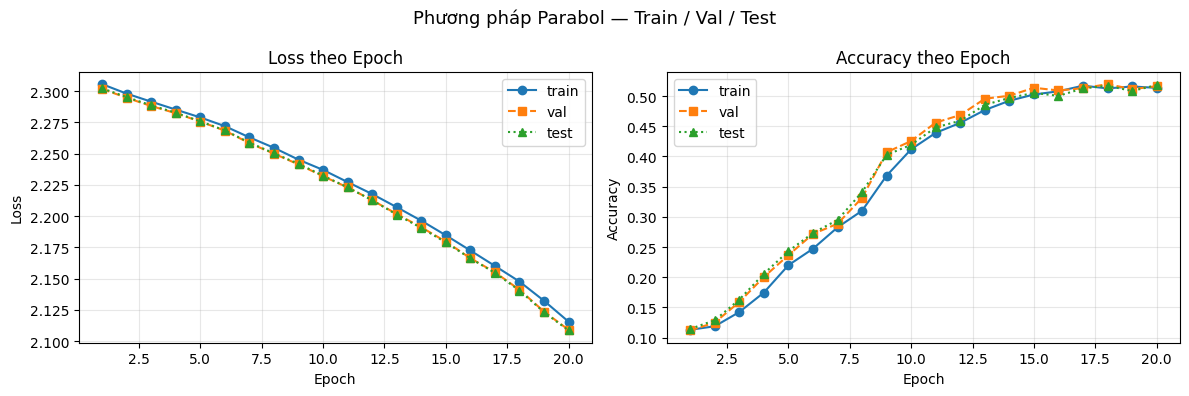

In [17]:
print(f"[Parabola] Accuracy cuối cùng — val: {history_para['val_acc'][-1]*100:.2f}%  |  test: {history_para['test_acc'][-1]*100:.2f}%")

epoch_axis_para = range(1, epochs_para + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Phương pháp Parabol — Train / Val / Test", fontsize=13)

# --- Biểu đồ Loss ---
axes[0].plot(epoch_axis_para, history_para["train_loss"], marker="o", label="train")
axes[0].plot(epoch_axis_para, history_para["val_loss"],   marker="s", label="val",  linestyle="--")
axes[0].plot(epoch_axis_para, history_para["test_loss"],  marker="^", label="test", linestyle=":")
axes[0].set_title("Loss theo Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Biểu đồ Accuracy ---
axes[1].plot(epoch_axis_para, history_para["train_acc"], marker="o", label="train")
axes[1].plot(epoch_axis_para, history_para["val_acc"],   marker="s", label="val",  linestyle="--")
axes[1].plot(epoch_axis_para, history_para["test_acc"],  marker="^", label="test", linestyle=":")
axes[1].set_title("Accuracy theo Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## So sánh hai phương pháp — Bảng tổng hợp

| | Gradient Descent | Phương pháp Parabol |
|--|--|--|
| **Công thức cập nhật** | $w \leftarrow w - \varepsilon \nabla_w E_B$ | $w \leftarrow w + \alpha^* d_t$ |
| **Nguồn thông tin** | Gradient $\nabla_w E_B$ (đạo hàm bậc 1) | 3 giá trị $E_-, E_0, E_+$ (zero-order) |
| **Cần `backward()`?** | **Có** | **Không** |
| **Forward/batch** | 1 forward + 1 backward | 4 forward, 0 backward |
| **Hướng cập nhật** | Hướng gradient (tối ưu) | Hướng ngẫu nhiên $d_t \sim \mathcal{N}(0,I)$ |
| **Epochs** | 20 | 20 |


In [18]:
comparison = pd.DataFrame([
    {
        "Phương pháp"      : "Gradient Descent",
        "Train samples"    : len(train_loader.dataset),
        "Val samples"      : len(val_loader.dataset),
        "Epochs"           : epochs_grad,
        "Val loss cuối"    : round(history_grad["val_loss"][-1],  4),
        "Val acc (%) cuối" : round(history_grad["val_acc"][-1]  * 100, 2),
        "Test loss cuối"   : round(history_grad["test_loss"][-1], 4),
        "Test acc (%) cuối": round(history_grad["test_acc"][-1] * 100, 2),
    },
    {
        "Phương pháp"      : "Parabol",
        "Train samples"    : len(train_loader.dataset),
        "Val samples"      : len(val_loader.dataset),
        "Epochs"           : epochs_para,
        "Val loss cuối"    : round(history_para["val_loss"][-1],  4),
        "Val acc (%) cuối" : round(history_para["val_acc"][-1]  * 100, 2),
        "Test loss cuối"   : round(history_para["test_loss"][-1], 4),
        "Test acc (%) cuối": round(history_para["test_acc"][-1] * 100, 2),
    },
])

comparison


,Phương pháp,Train samples,Val samples,Epochs,Val loss cuối,Val acc (%) cuối,Test loss cuối,Test acc (%) cuối
0,Gradient Descent,54000,6000,20,0.0809,97.45,0.0671,97.93
1,Parabol,54000,6000,20,2.1091,51.65,2.1086,51.83


## Nhận xét & Kết luận

| Phương pháp | Epochs | Val acc | Test acc | Val loss $E$ |
|-------------|--------|---------|----------|--------------|
| Gradient Descent | 20 | **97.45%** | **97.93%** | 0.0809 |
| Parabol | 20 | 51.65% | 51.83% | 2.1091 |

**Gradient Descent** hội tụ tốt: val acc ≈ test acc (chênh $0.48\%$) → không overfit, mạng học được đặc trưng thực sự.

**Parabol** chỉ đạt ~51% sau 20 epoch — gần ngưỡng lỗi khởi đầu ngẫu nhiên $E \approx \log(10) \approx 2.303$. Nguyên nhân: mỗi bước chỉ tối ưu 1 hướng ngẫu nhiên $d_t$ trong không gian $P \approx 100{,}000$ chiều, xác suất "trúng" hướng gradient $\approx 1/\sqrt{P} \approx 0.3\%$ → hội tụ rất chậm.


> **Kết luận:** Gradient Descent vượt trội hoàn toàn trên MNIST CNN (97.93% vs 51.83%). Phương pháp Parabol có giá trị minh họa **zero-order optimization** nhưng không thực tế cho mạng nhiều tham số.
